In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\plant_disease_dataset.csv")

In [3]:
df=data.copy()

In [4]:
df=df.astype(int)

In [5]:
df.head(4)

,temperature,humidity,rainfall,soil_pH,disease_present
0,27,33,0,4,1
1,24,36,42,8,0
2,28,34,16,6,1
3,32,41,20,6,0


In [6]:
df.describe()

,temperature,humidity,rainfall,soil_pH,disease_present
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.113100,61.644600,9.315600,5.774300,0.241000
std,5.818427,22.721266,9.844251,1.314737,0.427712
min,5.000000,6.000000,0.000000,4.000000,0.000000
25%,21.000000,40.000000,2.000000,5.000000,0.000000
50%,25.000000,72.000000,6.000000,6.000000,0.000000
75%,28.000000,81.000000,13.000000,7.000000,0.000000
max,56.000000,102.000000,84.000000,8.000000,1.000000


In [7]:
q1=df["temperature"].quantile(0.25)
q3=df["temperature"].quantile(0.75)

In [8]:
IQR=q3-q1
min=q1-(IQR*1.5)
max=q3+(IQR*1.5)

In [9]:
df=df[(df["temperature"]>min) & (df["temperature"]<max)]

In [10]:
q1=df["rainfall"].quantile(0.25)
q3=df["rainfall"].quantile(0.75)
IQR=q3-q1
min=q1-(IQR*1.5)
max=q3+(IQR*1.5)

In [11]:
df=df[(df["rainfall"]>min) & (df["rainfall"]<max)]

In [12]:

df.reset_index(inplace=True)

In [13]:
df.drop(columns="index",inplace=True)

In [14]:
df

,temperature,humidity,rainfall,soil_pH,disease_present
0,27,33,0,4,1
1,28,34,16,6,1
2,32,41,20,6,0
3,23,51,11,8,0
4,23,32,2,5,0
...,...,...,...,...,...
9273,31,81,22,5,1
9274,15,86,10,4,0
9275,21,81,13,7,0
9276,27,88,9,7,0


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x=df[["temperature","humidity","rainfall","soil_pH"]]
y=df["disease_present"]

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)

# logistic regression

In [18]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()

In [19]:
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
lg.score(x_test,y_test),lg.score(x_train,y_train)

(0.7706896551724138, 0.7788157516527738)

# decission tree 

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
for i in range(1,21):
    dc=DecisionTreeClassifier(max_depth=i)
    dc.fit(x_train,y_train)
    print(dc.score(x_test,y_test),dc.score(x_train,y_train),i)

0.7607758620689655 0.7723483759701063 1
0.7879310344827586 0.7933314170738718 2
0.7931034482758621 0.7999425122161541 3
0.8017241379310345 0.8036792181661397 4
0.8155172413793104 0.8146018970968669 5
0.8392241379310345 0.8443518252371371 6
0.8478448275862069 0.8562805403851681 7
0.8405172413793104 0.8626041966082207 8
0.8418103448275862 0.8696464501293475 9
0.8297413793103449 0.8801379706812302 10
0.8310344827586207 0.8893360160965795 11
0.8103448275862069 0.8995400977292325 12
0.8086206896551724 0.9116125323368784 13
0.7978448275862069 0.9241161253233687 14
0.7926724137931035 0.9351825237137108 15
0.7866379310344828 0.9452428858867491 16
0.7780172413793104 0.955590686979017 17
0.7780172413793104 0.9652198907732107 18
0.7668103448275863 0.9713998275366484 19
0.7650862068965517 0.9777234837597011 20


In [23]:
dc.score(x_test,y_test)

0.7650862068965517

# knn

In [24]:
from sklearn.neighbors import KNeighborsClassifier
for i in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    print(knn.score(x_test,y_test),knn.score(x_train,y_train),i)

0.740948275862069 0.9880712848519689 1
0.7810344827586206 0.8673469387755102 2
0.7875 0.8651911468812877 3
0.7943965517241379 0.8424834722621443 4
0.7978448275862069 0.8433457890198333 5
0.7974137931034483 0.8375970106352401 6
0.7995689655172413 0.8354412187410175 7
0.8021551724137931 0.8272492095429721 8
0.7991379310344827 0.8318482322506467 9
0.7982758620689655 0.8225064673756827 10
0.803448275862069 0.823943661971831 11
0.7969827586206897 0.8220753089968381 12
0.7987068965517241 0.8202069560218453 13
0.7982758620689655 0.818769761425697 14
0.7935344827586207 0.8180511641276229 15
0.7935344827586207 0.81618281115263 16
0.7939655172413793 0.8177637252083932 17
0.7982758620689655 0.8154642138545559 18
0.7978448275862069 0.817045127910319 19
0.7926724137931035 0.817907444668008 20


# bayes low

In [25]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB

In [26]:
gs=GaussianNB()
gs.fit(x_train,y_train)
gs.score(x_test,y_test)

0.784051724137931

In [27]:
br=BernoulliNB()
br.fit(x_train,y_train)
br.score(x_test,y_test)

0.7607758620689655

In [28]:
mr=MultinomialNB()
mr.fit(x_train,y_train)
mr.score(x_test,y_test)

0.7237068965517242

# random forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
for i in range(1,21):
    rd=RandomForestClassifier(n_estimators=i) 
    rd.fit(x_train,y_train)
    print(rd.score(x_test,y_test),rd.score(x_train,y_train),i)

0.7685344827586207 0.9014084507042254 1
0.7952586206896551 0.9163552745041679 2
0.7952586206896551 0.9527162977867203 3
0.8172413793103448 0.9449554469675194 4
0.8116379310344828 0.9620580626616844 5
0.8150862068965518 0.9596148318482323 6
0.8228448275862069 0.9662259269905145 7
0.8181034482758621 0.964070135096292 8
0.821551724137931 0.9738430583501007 9
0.8189655172413793 0.9680942799655073 10
0.821551724137931 0.9762862891635528 11
0.8219827586206897 0.9729807415924117 12
0.8241379310344827 0.9781546421385455 13
0.8254310344827587 0.9752802529462489 14
0.8232758620689655 0.9800229951135384 15
0.8280172413793103 0.9794481172750791 16
0.8241379310344827 0.9821787870077608 17
0.8293103448275863 0.9811727507904571 18
0.8262931034482759 0.9804541534923829 19
0.8219827586206897 0.9790169588962345 20


# votting

In [30]:
from sklearn.ensemble import VotingClassifier
vt=VotingClassifier(estimators=[("lr",LogisticRegression()),("br",BernoulliNB()),("dc",DecisionTreeClassifier())])

In [31]:
vt.fit(x_train,y_train)

,estimators,"[('lr', ...), ('br', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [32]:
vt.score(x_test,y_test)

0.771551724137931

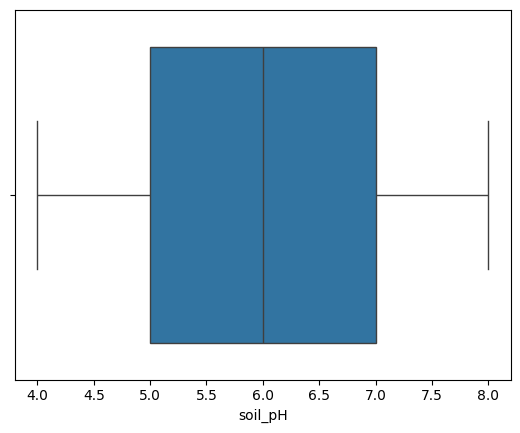

In [33]:
sns.boxplot(x="soil_pH",data=df)
plt.show()

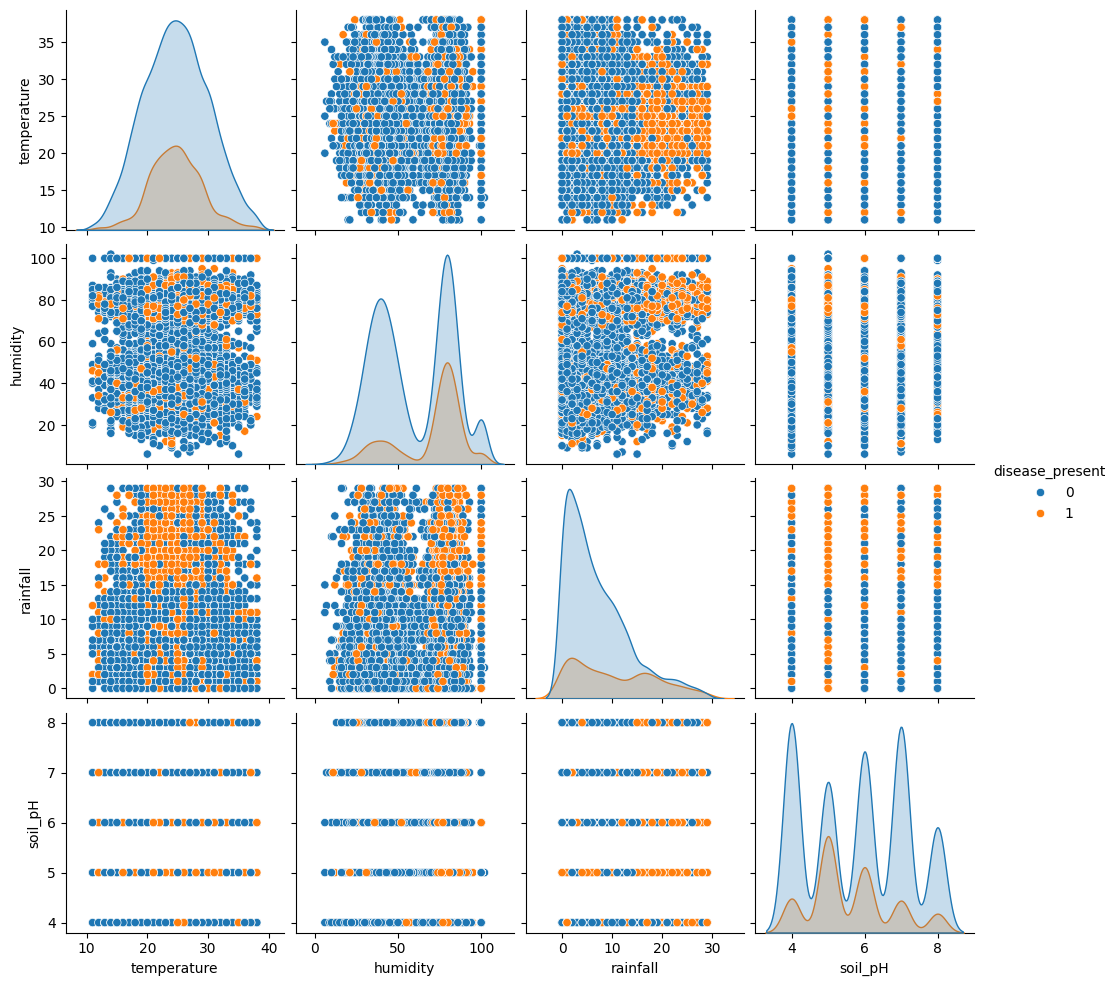

In [34]:
sns.pairplot(data=df,hue="disease_present")
plt.show()

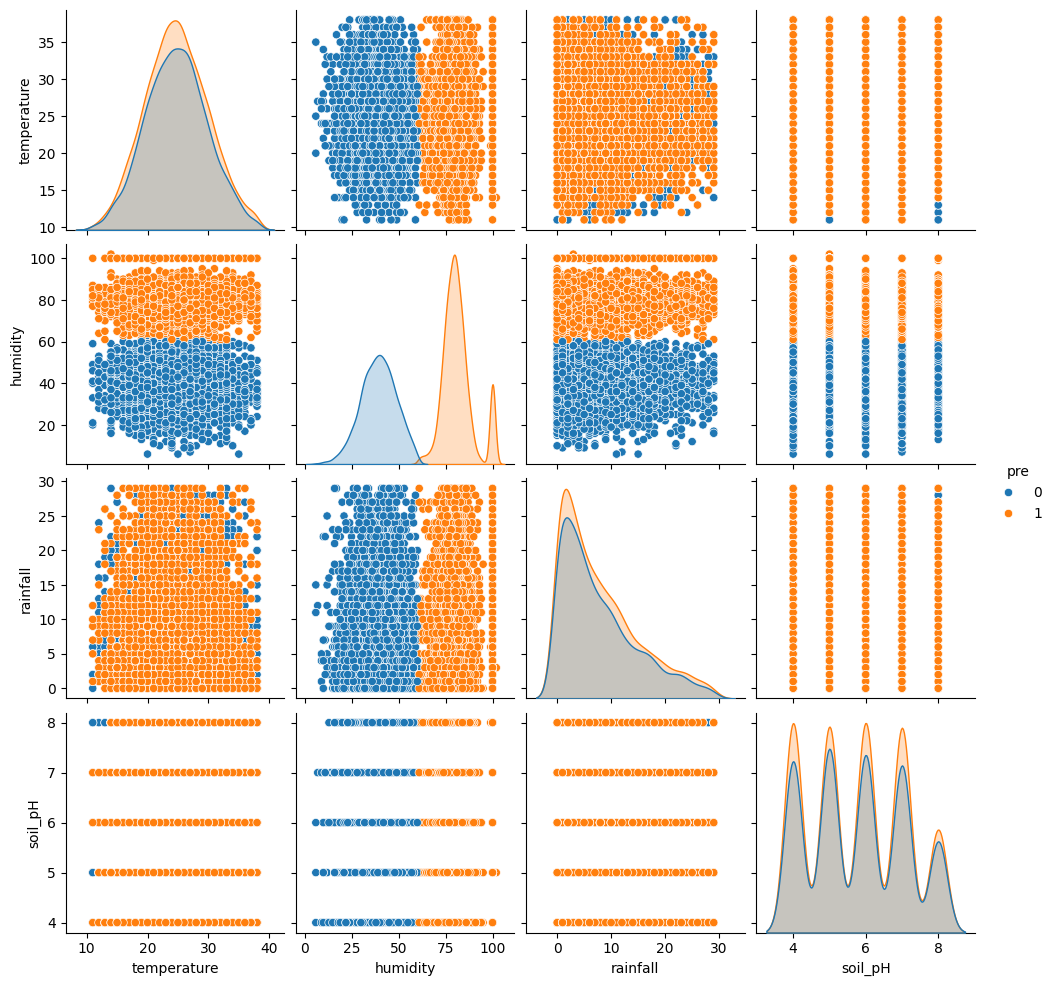

In [46]:
sns.pairplot(data=x,hue="pre")
plt.show()

# clustering

In [37]:
from sklearn.cluster import KMeans

In [38]:
list=[]
for i in range(1,21):
    km=KMeans(n_clusters=i,init='k-means++')
    km.fit_predict(x)
    list.append(km.inertia_)

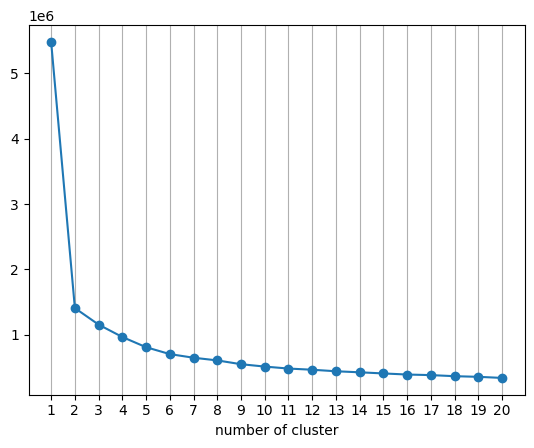

In [40]:
plt.plot([i for i in range(1,21)],list,marker="o")
plt.xlabel("number of cluster")
plt.xticks([i for i in range(1,21)])
plt.grid(axis="x")
plt.show()

In [42]:
kn=KMeans(n_clusters=2)
kn.fit(x)
x["pre"]=kn.predict(x)

In [44]:
x["pre"].value_counts()


pre
1    4961
0    4317
Name: count, dtype: int64

In [45]:
y.value_counts()

disease_present
0    7139
1    2139
Name: count, dtype: int64

In [48]:
from sklearn.cluster import DBSCAN

In [ ]:
db=DBSCAN(eps=)